# Retest `fold_1_model_best.pt` on the original validation fold

This notebook reconstructs the **exact record-wise fold split** used in your cross-validation training script and then evaluates `fold_1_model_best.pt` on the **same validation set that fold 1 used during training**.

It mirrors the logic from your training code, including:

- `KFold(n_splits=5, shuffle=True, random_state=154727)`
- splitting on `unique_records = np.unique(record_ids)`
- the same `SleepDataset`
- the same `SlumberNetPT` architecture
- loading `fold_1_model_best.pt` and evaluating on fold 1's validation records

Update the file paths in the next cell before running.


In [1]:

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    cohen_kappa_score,
    explained_variance_score,
    log_loss,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================================================
# Paths: update these
# =========================================================

data_path = r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\preprocessed\sleep_edf_all_epochs.npz"
model_path = r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\k-fold_models_pytorch\fold_1_model_best.pt"
output_dir = r"C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest"
os.makedirs(output_dir, exist_ok=True)

# =========================================================
# Config copied from training
# =========================================================

seed = 154727
num_folds = 5
batch_size = 64
num_workers = 0

dropout_rate = 0.1
n_resnet_blocks = 7
n_feature_maps = 8
kernel_expansion_fct = 1
kernel_y = 2

use_initial_pool = True
initial_pool_kernel = (4, 1)

CLASS_NAMES = ["W", "N1", "N2", "N3", "REM"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(seed)


Using device: cuda
CUDA device: NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:

# =========================================================
# Load data
# =========================================================

data = np.load(data_path, allow_pickle=True)

X = data["X"].astype(np.float32)
y = data["y"].astype(np.int64)
record_ids = data["record_id"]
channel_names = list(data["channel_names"])
sfreq = float(data["sfreq"][0])

print("Loaded arrays:")
print("  X raw shape:", X.shape)
print("  y shape:", y.shape)
print("  record_ids shape:", record_ids.shape)
print("  channel_names:", channel_names)
print("  sfreq:", sfreq)

n_samples, n_channels, n_timepoints = X.shape
nb_classes = len(np.unique(y))

if nb_classes != len(CLASS_NAMES):
    CLASS_NAMES = [str(i) for i in range(nb_classes)]

print("n_samples:", n_samples)
print("n_channels:", n_channels)
print("n_timepoints:", n_timepoints)
print("nb_classes:", nb_classes)
print("CLASS_NAMES:", CLASS_NAMES)


Loaded arrays:
  X raw shape: (206034, 2, 3000)
  y shape: (206034,)
  record_ids shape: (206034,)
  channel_names: ['Fpz-Cz', 'Pz-Oz']
  sfreq: 100.0
n_samples: 206034
n_channels: 2
n_timepoints: 3000
nb_classes: 5
CLASS_NAMES: ['W', 'N1', 'N2', 'N3', 'REM']


In [3]:

# =========================================================
# Dataset
# =========================================================

class SleepDataset(Dataset):
    """
    Expects X in shape (N, C, T).
    Returns tensors in shape (1, T, C).
    """
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def _augment(self, x):
        amp = np.random.uniform(0.9, 1.1, size=(x.shape[0], 1)).astype(np.float32)
        x = x * amp
        shift = np.random.randint(-200, 201)
        x = np.roll(x, shift=shift, axis=1)
        return x

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        target = self.y[idx]

        if self.augment:
            x = self._augment(x)

        x = np.transpose(x, (1, 0))
        x = np.expand_dims(x, axis=0)

        return torch.tensor(x, dtype=torch.float32), torch.tensor(target, dtype=torch.long)


In [4]:

# =========================================================
# Model definition copied from training
# =========================================================

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_y=2, kernel_expansion_fct=1, dropout_rate=0.0):
        super().__init__()

        self.conv_x = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=(kernel_y, 8 * kernel_expansion_fct),
            padding="same",
        )
        self.bn_x = nn.BatchNorm2d(out_channels)

        self.conv_y = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=(kernel_y, 5 * kernel_expansion_fct),
            padding="same",
        )
        self.bn_y = nn.BatchNorm2d(out_channels)

        self.conv_z = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=(kernel_y, 3 * kernel_expansion_fct),
            padding="same",
        )
        self.bn_z = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1), padding="same"),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.BatchNorm2d(out_channels)

        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        out = self.conv_x(x)
        out = self.bn_x(out)
        out = self.dropout(out)
        out = self.relu(out)

        out = self.conv_y(out)
        out = self.bn_y(out)
        out = self.dropout(out)
        out = self.relu(out)

        out = self.conv_z(out)
        out = self.bn_z(out)

        identity = self.shortcut(identity)
        out = out + identity
        out = self.dropout(out)
        out = self.relu(out)
        return out


class FinalResidualBlock(nn.Module):
    def __init__(self, channels, kernel_y=2, kernel_expansion_fct=1, dropout_rate=0.0):
        super().__init__()

        self.conv_x = nn.Conv2d(
            channels, channels,
            kernel_size=(kernel_y, 8 * kernel_expansion_fct),
            padding="same"
        )
        self.bn_x = nn.BatchNorm2d(channels)

        self.conv_y = nn.Conv2d(
            channels, channels,
            kernel_size=(kernel_y, 8 * kernel_expansion_fct),
            padding="same"
        )
        self.bn_y = nn.BatchNorm2d(channels)

        self.conv_z = nn.Conv2d(
            channels, channels,
            kernel_size=(kernel_y, 8 * kernel_expansion_fct),
            padding="same"
        )
        self.bn_z = nn.BatchNorm2d(channels)

        self.shortcut_bn = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = self.shortcut_bn(x)

        out = self.conv_x(x)
        out = self.bn_x(out)
        out = self.relu(out)

        out = self.conv_y(out)
        out = self.bn_y(out)
        out = self.relu(out)

        out = self.conv_z(out)
        out = self.bn_z(out)

        out = out + identity
        out = self.dropout(out)
        out = self.relu(out)
        return out


class SlumberNetPT(nn.Module):
    def __init__(
        self,
        nb_classes,
        n_resnet_blocks=7,
        n_feature_maps=8,
        kernel_y=2,
        kernel_expansion_fct=1,
        dropout_rate=0.0,
        use_initial_pool=True,
        initial_pool_kernel=(4, 1),
    ):
        super().__init__()

        self.use_initial_pool = use_initial_pool
        if self.use_initial_pool:
            self.initial_pool = nn.AvgPool2d(kernel_size=initial_pool_kernel)

        blocks = []
        in_channels = 1

        for i in range(n_resnet_blocks - 1):
            out_channels = n_feature_maps * (2 ** i)
            blocks.append(
                ResidualBlock(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_y=kernel_y,
                    kernel_expansion_fct=kernel_expansion_fct,
                    dropout_rate=dropout_rate,
                )
            )
            in_channels = out_channels

        self.res_blocks = nn.Sequential(*blocks)

        self.final_block = FinalResidualBlock(
            channels=in_channels,
            kernel_y=kernel_y,
            kernel_expansion_fct=kernel_expansion_fct,
            dropout_rate=dropout_rate,
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(in_channels, nb_classes)

    def forward(self, x):
        if self.use_initial_pool:
            x = self.initial_pool(x)

        x = self.res_blocks(x)
        x = self.final_block(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [5]:

# =========================================================
# Evaluation helper
# =========================================================

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_targets = []
    all_preds = []
    all_probs = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        running_loss += loss.item() * xb.size(0)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

        all_targets.append(yb.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)

    return epoch_loss, epoch_acc, y_true, y_pred, y_prob


def load_checkpoint_flex(model, checkpoint_path, device):
    state_dict = torch.load(checkpoint_path, map_location=device)

    try:
        model.load_state_dict(state_dict)
        print("Loaded checkpoint directly.")
        return model
    except RuntimeError:
        pass

    stripped_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            stripped_state_dict[k[len("module."):]] = v
        else:
            stripped_state_dict[k] = v

    model.load_state_dict(stripped_state_dict)
    print("Loaded checkpoint after stripping 'module.' prefixes.")
    return model


In [6]:

# =========================================================
# Rebuild the exact fold split and isolate fold 1 val set
# =========================================================

unique_records = np.unique(record_ids)
print(f"Unique recordings: {len(unique_records)}")

kf = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
fold_splits = list(kf.split(unique_records))

fold_num = 1
train_record_idx, val_record_idx = fold_splits[fold_num - 1]

train_records = unique_records[train_record_idx]
val_records = unique_records[val_record_idx]

train_mask = np.isin(record_ids, train_records)
val_mask = np.isin(record_ids, val_records)

X_val = X[val_mask]
y_val = y[val_mask]
val_record_ids = record_ids[val_mask]

print(f"Fold {fold_num} validation set:")
print("  validation records:", len(val_records))
print("  validation samples:", len(y_val))

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

val_dataset = SleepDataset(X_val, y_val, augment=False)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available(),
)


Unique recordings: 178
Fold 1 validation set:
  validation records: 36
  validation samples: 40621

Validation class counts:
0    10448
1     3923
2    14902
3     5020
4     6328
Name: count, dtype: int64


In [7]:

# =========================================================
# Build model and load fold_1_model_best.pt
# =========================================================

model = SlumberNetPT(
    nb_classes=nb_classes,
    n_resnet_blocks=n_resnet_blocks,
    n_feature_maps=n_feature_maps,
    kernel_y=kernel_y,
    kernel_expansion_fct=kernel_expansion_fct,
    dropout_rate=dropout_rate,
    use_initial_pool=use_initial_pool,
    initial_pool_kernel=initial_pool_kernel,
).to(device)

model = load_checkpoint_flex(model, model_path, device)

criterion = nn.CrossEntropyLoss()


Loaded checkpoint directly.


In [ ]:

# =========================================================
# Evaluate
# =========================================================

val_loss, val_acc, y_true, y_pred, y_prob = evaluate(model, val_loader, criterion, device)


c:\Users\ryanz\anaconda3\envs\compsci682\Lib\site-packages\torch\nn\modules\conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv2d(


ValueError: The object was not fitted with multilabel input.

In [9]:
precision, recall, f1_score, support = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
acc = accuracy_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred, labels=np.arange(nb_classes))
kappa = cohen_kappa_score(y_true, y_pred)
val_log_loss = log_loss(y_true, y_prob, labels=np.arange(nb_classes))
exp_var = explained_variance_score(y_true, y_pred)

metrics_df = pd.DataFrame([{
    "fold": fold_num,
    "loss": val_loss,
    "accuracy": acc,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1_score,
    "cohen_kappa": kappa,
    "log_loss": val_log_loss,
    "explained_variance": exp_var,
    "n_samples": len(y_true),
    "n_records": len(val_records),
}])

metrics_df


,fold,loss,accuracy,precision_weighted,recall_weighted,f1_weighted,cohen_kappa,log_loss,explained_variance,n_samples,n_records
0,1,0.683346,0.768248,0.760156,0.768248,0.756127,0.682743,0.683276,0.563928,40621,36


In [10]:

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


              precision    recall  f1-score   support

           W       0.96      0.85      0.90     10448
          N1       0.37      0.18      0.25      3923
          N2       0.72      0.90      0.80     14902
          N3       0.82      0.75      0.78      5020
         REM       0.71      0.70      0.71      6328

    accuracy                           0.77     40621
   macro avg       0.72      0.68      0.69     40621
weighted avg       0.76      0.77      0.76     40621



In [11]:

# =========================================================
# Save outputs
# =========================================================

metrics_csv = os.path.join(output_dir, "fold_1_retest_metrics.csv")
preds_csv = os.path.join(output_dir, "fold_1_retest_predictions.csv")
cm_csv = os.path.join(output_dir, "fold_1_retest_confusion_matrix.csv")

metrics_df.to_csv(metrics_csv, index=False)

preds_df = pd.DataFrame({
    "record_id": val_record_ids,
    "y_true": y_true,
    "y_pred": y_pred,
})
for i, class_name in enumerate(CLASS_NAMES):
    preds_df[f"prob_{class_name}"] = y_prob[:, i]
preds_df.to_csv(preds_csv, index=False)

cm_df = pd.DataFrame(conf_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(cm_csv)

print("Saved:")
print(" ", metrics_csv)
print(" ", preds_csv)
print(" ", cm_csv)


Saved:
  C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest\fold_1_retest_metrics.csv
  C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest\fold_1_retest_predictions.csv
  C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest\fold_1_retest_confusion_matrix.csv


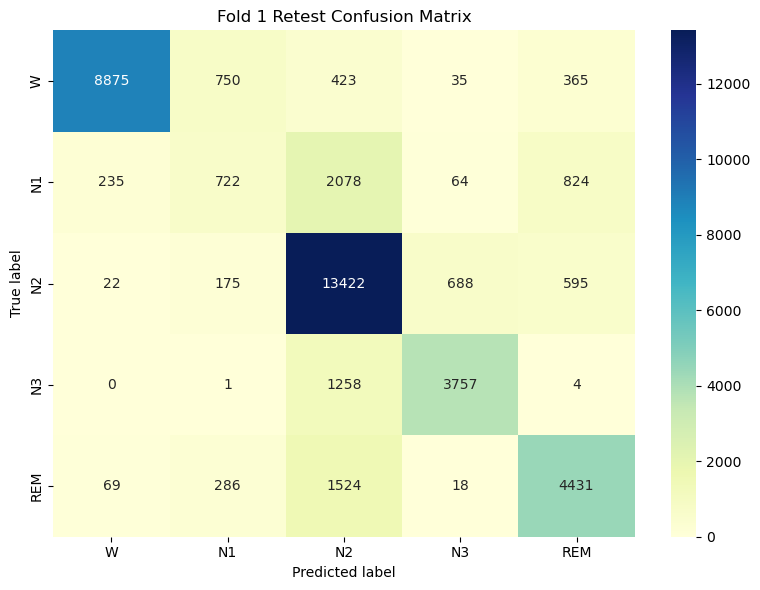

Saved:
  C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest\fold_1_retest_confusion_matrix.png
  C:\Users\ryanz\Documents\somneuro\sleepnet\data\output\fold_1_retest\fold_1_retest_confusion_matrix.pdf


In [12]:

# =========================================================
# Confusion matrix plot
# =========================================================

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="YlGnBu",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title("Fold 1 Retest Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

png_path = os.path.join(output_dir, "fold_1_retest_confusion_matrix.png")
pdf_path = os.path.join(output_dir, "fold_1_retest_confusion_matrix.pdf")
plt.savefig(png_path)
plt.savefig(pdf_path)
plt.show()

print("Saved:")
print(" ", png_path)
print(" ", pdf_path)


## Notes

This notebook will only match the original fold if all of these are unchanged from training:

1. the same `.npz` file
2. the same `seed = 154727`
3. the same `num_folds = 5`
4. the same `np.unique(record_ids)` ordering
5. the same model hyperparameters

Because your training script used the fold's held-out split as `test_loader` and passed it into `fit_fold(..., val_loader=test_loader, ...)`, this notebook recreates that same held-out fold and evaluates on it again.
